# 산탄데르 고객만족예측 - 통합 최적화

`report/` 폴더에 있던 팀원별 노트북(HH-GBM, JH-XGBoost, SH-XGBoost/LightGBM, YG-RandomForest/LogisticRegression x3, YW-전체 파이프라인) 8개를 검토해서, 중복 코드를 공용 함수로 묶고 모델별 최적 전략만 남겨 하나로 합친 노트북입니다.

모두 실행으로 처음부터 끝까지 그대로 실행되도록 만들어뒀습니다. 다만 XGBoost Hyperopt(200회)와 LightGBM GridSearchCV(729조합) 구간이 포함돼 있어 전체 실행에 시간이 꽤 걸릴 수 있습니다(참고: 팀 실측 기준 XGBoost Hyperopt 수십 분, LightGBM GridSearchCV 약 19분).

## 1. 공통 설정

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, GridSearchCV, PredefinedSplit
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from scipy.stats import randint, uniform

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

RANDOM_STATE = 156
DATA_PATH = "../../data/santander-customer-satisfaction/train.csv"

print('라이브러리 로드 완료')
# 4.5s

라이브러리 로드 완료


In [ ]:
# 원본 데이터 로드 (ID를 인덱스로, 이후 모든 전처리 함수는 이 raw_df를 복사해서 시작한다)
raw_df = pd.read_csv(DATA_PATH, index_col=0)
y_labels = raw_df['TARGET'].copy()

print('원본 Shape:', raw_df.shape)
print('TARGET 분포:')
print(y_labels.value_counts())
print(y_labels.value_counts(normalize=True).round(4))
# 2.8s

원본 Shape: (76020, 370)
TARGET 분포:
TARGET
0    73012
1     3008
Name: count, dtype: int64
TARGET
0    0.9604
1    0.0396
Name: proportion, dtype: float64


## 2. 간단 EDA

전처리 방향을 결정한 핵심 근거 2가지만 확인합니다. 더 자세한 EDA(상관관계, 파생변수 히트맵 등)는 `report/HH`, 보고서 3장을 참고하세요.

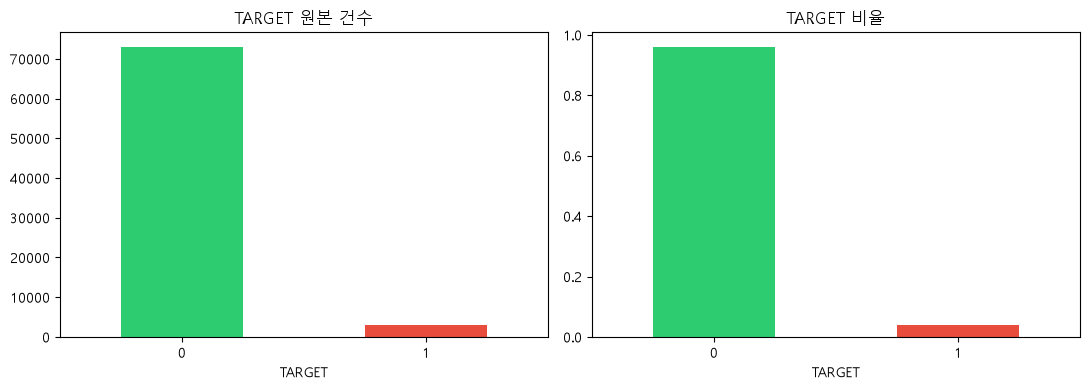

클래스 불균형 비율 약 24.3 : 1

var3 == -999999 개수: 116
delta_* == 9999999999 개수: 1194
var38 왜도(치우침 정도): 51.27


In [ ]:
# (1) 클래스 불균형 확인
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
y_labels.value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('TARGET 원본 건수')
axes[0].tick_params(axis='x', rotation=0)

y_labels.value_counts(normalize=True).plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('TARGET 비율')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print(f"클래스 불균형 비율 약 {(y_labels == 0).sum() / (y_labels == 1).sum():.1f} : 1")

# (2) 결측이 sentinel 값으로 위장된 것 확인
print('\nvar3 == -999999 개수:', (raw_df['var3'] == -999999).sum())
delta_cols_check = [c for c in raw_df.columns if c.startswith('delta_')]
print('delta_* == 9999999999 개수:', (raw_df[delta_cols_check] == 9999999999).sum().sum())
print('var38 왜도(치우침 정도):', round(raw_df['var38'].skew(), 2))
# 0.3

## 3. 공용 함수

8개 노트북에서 거의 그대로 반복되던 코드를 함수로 정리했습니다. 이후 모델 섹션은 전부 이 함수들을 조합해서 씁니다.

In [ ]:
# --- 이상치 처리 ---

def fix_var3(X):
    """var3의 결측 이상치(-999999)를 최빈값 2로 치환 (모든 모델 공통)"""
    X = X.copy()
    X['var3'] = X['var3'].replace(-999999, 2)
    return X


def fix_delta_outliers(X, add_flag=False):
    """delta_* 컬럼의 이상치(9999999999)를 처리.
    add_flag=False (기본, XGB/GBM/LightGBM/RF/LR용): NaN 처리 후 컬럼별 중앙값으로 대체.
    add_flag=True  (Decision Tree용): 대체하기 전에 '행마다 이상치였던 delta_* 개수'를
                    delta_missing_cnt 피처로 먼저 남겨서, 대체로 사라지는 정보를 보존한다.
    """
    X = X.copy()
    delta_cols = [c for c in X.columns if c.startswith('delta_')]
    if add_flag:
        X['delta_missing_cnt'] = (X[delta_cols] == 9999999999).sum(axis=1)
    X[delta_cols] = X[delta_cols].replace(9999999999, np.nan)
    X[delta_cols] = X[delta_cols].fillna(X[delta_cols].median())
    return X


# --- 파생 변수 ---

def add_row_stats(X, full=True):
    """행(row) 단위 파생 변수 추가.
    full=True  (XGB/GBM/LightGBM/LR용): n0 + row_std/mean/median/max/min/range + n_negative (8개, HH안).
    full=False (DT/RF용): n0 (+ RF는 이후 var38_is_missing을 별도로 추가) 만 사용.
    """
    X = X.copy()
    X['n0'] = (X == 0).sum(axis=1)
    # 주의(원본 HH 노트북과 동일한 순서 유지): n0를 먼저 추가한 뒤 row_std 등을 계산하므로
    # n0 컬럼 자체도 행 통계량 계산에 함께 섞여 들어간다. 팀이 실측 검증한 점수들이 전부
    # 이 순서 기준이라 여기서는 그대로 두되, 엄밀하게 분리하고 싶다면 n0 계산을 뒤로 미루면 된다.
    if full:
        X['row_std'] = X.std(axis=1)
        X['row_mean'] = X.mean(axis=1)
        X['row_median'] = X.median(axis=1)
        X['row_max'] = X.max(axis=1)
        X['row_min'] = X.min(axis=1)
        X['row_range'] = X['row_max'] - X['row_min']
        X['n_negative'] = (X < 0).sum(axis=1)
    return X


# --- 컬럼 정제 ---

MANUAL_NOISE_COLS = [
    'delta_imp_reemb_var13_1y3', 'delta_imp_reemb_var17_1y3',
    'delta_imp_trasp_var17_in_1y3', 'delta_imp_trasp_var33_in_1y3',
]

def remove_useless_columns(X):
    """상수 컬럼 + 완전 중복 컬럼 + 수동 노이즈 컬럼(var6 계열, 왜곡 심한 delta_* 4개) 제거.
    상수 컬럼을 먼저 제거한 뒤 중복을 검사해야 한다(안 그러면 서로 값이 같은 상수 컬럼끼리
    중복으로 잡혀 개수가 부풀려진다)."""
    X = X.copy()
    const_cols = [c for c in X.columns if X[c].nunique() == 1]
    X = X.drop(columns=const_cols)

    dup_cols = X.columns[X.T.duplicated()].tolist()
    X = X.drop(columns=dup_cols)

    manual_remove = [c for c in X.columns if 'var6' in c] + MANUAL_NOISE_COLS
    manual_remove = [c for c in manual_remove if c in X.columns]
    X = X.drop(columns=manual_remove)

    print(f'  상수 컬럼 제거: {len(const_cols)}개, 중복 컬럼 제거: {len(dup_cols)}개, '
          f'수동 노이즈 제거: {len(manual_remove)}개 -> 남은 컬럼 {X.shape[1]}개')
    return X


# --- 데이터 분할 ---

def split_train_val_test(X, y, test_size=0.2, val_size=0.3, random_state=0):
    """1차: 학습(80%)/최종테스트(20%) 분리, 2차: 학습을 다시 훈련/검증으로 분리.
    모든 팀원이 공통으로 지킨 원칙: stratify + 훈련 세트 기준으로만 이후 전처리를 fit."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state)
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=val_size, stratify=y_train, random_state=random_state)
    return X_train, X_tr, X_val, X_test, y_train, y_tr, y_val, y_test


# --- 피처 중요도 기반 가지치기 ---

def prune_zero_importance(fitted_model, X_tr, X_val, X_test):
    """fitted_model.feature_importances_ 기준으로 importance=0인 컬럼을 세 세트에서 동일하게 제거."""
    importances = pd.Series(fitted_model.feature_importances_, index=X_tr.columns)
    zero_cols = importances[importances == 0].index.tolist()
    print(f'  importance=0 피처 {len(zero_cols)}개 제거 (전체 {len(importances)}개 중)')
    return (X_tr.drop(columns=zero_cols), X_val.drop(columns=zero_cols),
            X_test.drop(columns=zero_cols), zero_cols)


# --- 스케일링 + PCA (X_tr 기준으로만 fit) ---

def add_pca_features(X_tr, X_val, X_test, n_components=5, random_state=156):
    """StandardScaler + PCA를 X_tr로만 학습(fit)하고, 나온 주성분을 원본 피처에 추가 컬럼(pca1..)으로 붙인다.
    (원본 피처를 대체하는 게 아니라 '원본 + 압축된 전역 패턴'을 함께 제공하는 방식)"""
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    pca = PCA(n_components=n_components, random_state=random_state)
    pca_tr = pca.fit_transform(X_tr_scaled)
    pca_val = pca.transform(X_val_scaled)
    pca_test = pca.transform(X_test_scaled)

    X_tr, X_val, X_test = X_tr.copy(), X_val.copy(), X_test.copy()
    for i in range(n_components):
        X_tr[f'pca{i+1}'] = pca_tr[:, i]
        X_val[f'pca{i+1}'] = pca_val[:, i]
        X_test[f'pca{i+1}'] = pca_test[:, i]
    return X_tr, X_val, X_test, scaler, pca


# --- WOE(Weight of Evidence) 인코딩 (유경, 로지스틱 회귀 전용) ---

def fit_woe(X, y, n_bins=10):
    """X_tr 기준으로 컬럼별 구간 경계와 WOE 값 산출"""
    bin_edges, woe_maps = {}, {}
    total_good, total_bad = (y == 0).sum(), (y == 1).sum()
    eps = 0.5  # 구간 내 이벤트 0건일 때 log(0) 방지용 보정

    for col in X.columns:
        try:
            binned, edges = pd.qcut(X[col], q=n_bins, retbins=True, duplicates='drop')
        except ValueError:
            binned, edges = X[col], None

        df_bin = pd.DataFrame({'bin': binned, 'y': y.values})
        grouped = df_bin.groupby('bin', observed=True)['y'].agg(['sum', 'count'])
        good, bad = grouped['count'] - grouped['sum'], grouped['sum']

        woe = np.log(((good + eps) / total_good) / ((bad + eps) / total_bad))
        bin_edges[col], woe_maps[col] = edges, woe.to_dict()
    return bin_edges, woe_maps


def transform_woe(X, bin_edges, woe_maps):
    """fit_woe에서 산출한 구간 경계/WOE 값으로 X를 변환 (X_val, X_test에 사용)"""
    X_woe = pd.DataFrame(index=X.index)
    for col in X.columns:
        edges = bin_edges[col]
        binned = pd.cut(X[col], bins=edges, include_lowest=True) if edges is not None else X[col]
        X_woe[col] = binned.astype(object).map(woe_maps[col]).fillna(0.0).astype(float)
    return X_woe


# --- Hyperopt 공용 목적함수 템플릿 (HH의 GBM objective, JH의 XGBoost objective_func를 일반화) ---

def make_hyperopt_objective(model_cls, X, y, int_params=(), n_splits=3, random_state=RANDOM_STATE, fixed_params=None):
    """model_cls(GradientBoostingClassifier, XGBClassifier 등)에 대한 Hyperopt objective를 생성.
    int_params에 지정된 파라미터는 int로 변환(hp.quniform은 float를 반환하므로 필요)."""
    fixed_params = fixed_params or {}

    def objective(params):
        p = {k: (int(v) if k in int_params else v) for k, v in params.items()}
        kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        aucs = []
        for tr_idx, val_idx in kf.split(X, y):
            clf = model_cls(random_state=random_state, **fixed_params, **p)
            clf.fit(X.iloc[tr_idx], y.iloc[tr_idx])
            pred = clf.predict_proba(X.iloc[val_idx])[:, 1]
            aucs.append(roc_auc_score(y.iloc[val_idx], pred))
        return {'loss': -np.mean(aucs), 'status': STATUS_OK}
    return objective


def run_hyperopt(objective, space, max_evals=30, random_state=RANDOM_STATE):
    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=max_evals,
                trials=trials, rstate=np.random.default_rng(random_state), show_progressbar=True)
    best_cv_auc = -trials.best_trial['result']['loss']
    return best, best_cv_auc, trials


# --- 결과 출력 ---

def print_auc(name, score, note=''):
    print(f'[{name}] ROC-AUC = {score:.4f}' + (f'  ({note})' if note else ''))


def report_auc(results, baseline=None):
    """{'모델명': auc, ...} 형태의 결과를 표로 출력"""
    print(f"{'모델':30s} {'ROC-AUC':>10s}" + (f"{'baseline대비':>14s}" if baseline else ''))
    base_score = results.get(baseline) if baseline else None
    for name, score in results.items():
        line = f'{name:30s} {score:>10.4f}'
        if base_score is not None:
            line += f'{score - base_score:>+14.4f}'
        print(line)
    return {'best_model': max(results, key=results.get), 'best_score': max(results.values())}


print('공용 함수 정의 완료')
# 0.0s

공용 함수 정의 완료


## 4. 공통 전처리 - 부스팅 계열(XGBoost / GBM / LightGBM) 공용

세 모델 모두 "이상치 치환 -> var38 로그변환 -> 파생변수 -> 컬럼 정제 -> 분할 -> (X_tr 기준) PCA 추가"라는 동일한 전처리를 공유합니다.
(개별 노트북에서는 컬럼정제 유무·파생변수 개수가 조금씩 달랐는데, 여기서는 가장 촘촘했던 혜현의 버전을 공통 버전으로 채택했습니다 - 실측으로도 중요도 0 처리에서 어차피 걸러지는 컬럼들이라 손해가 없습니다.)

In [ ]:
X_c = fix_var3(raw_df.drop(columns=['TARGET']))
X_c['var38'] = np.log1p(X_c['var38'])          # 왜도 51.27 -> 로그로 완화
X_c = add_row_stats(X_c, full=True)             # n0 + row_std/mean/median/max/min/range + n_negative
print('파생변수 추가 후:', X_c.shape)

X_c = remove_useless_columns(X_c)

X_train_c, X_tr_c, X_val_c, X_test_c, y_train_c, y_tr_c, y_val_c, y_test_c = split_train_val_test(X_c, y_labels)
print(f'훈련(X_tr_c) {X_tr_c.shape}, 검증(X_val_c) {X_val_c.shape}, 테스트(X_test_c) {X_test_c.shape}')

# PCA는 X_tr_c 기준으로만 fit (데이터 누수 방지), 5개 컴포넌트를 원본 피처에 추가
X_tr_c, X_val_c, X_test_c, scaler_c, pca_c = add_pca_features(X_tr_c, X_val_c, X_test_c, n_components=5)
# X_train_c(80% 전체)에도 동일하게 적용해둬야 '전체 훈련세트로 최종 재학습'할 때 쓸 수 있다
X_train_c_scaled = scaler_c.transform(X_train_c)
pca_train_c = pca_c.transform(X_train_c_scaled)
X_train_c = X_train_c.copy()
for i in range(5):
    X_train_c[f'pca{i+1}'] = pca_train_c[:, i]

print('PCA 추가 후 최종 shape:', X_tr_c.shape)
# 15.8s

파생변수 추가 후: (76020, 377)
  상수 컬럼 제거: 35개, 중복 컬럼 제거: 29개, 수동 노이즈 제거: 9개 -> 남은 컬럼 304개
훈련(X_tr_c) (42571, 304), 검증(X_val_c) (18245, 304), 테스트(X_test_c) (15204, 304)
PCA 추가 후 최종 shape: (42571, 309)


## 5. XGBoost

용우의 베이스라인(`n_estimators=500, learning_rate=0.05, early_stopping_rounds=100`) + 중요도 0 가지치기,
그리고 진희가 시도한 Hyperopt(TPE) 튜닝(테스트 0.8255, 팀 내 XGBoost 최고 기록)을 공용 함수로 재구현해서 둘 다 담았습니다.

In [ ]:
# --- 5.1 베이스라인 ---
xgb_clf = XGBClassifier(
    n_estimators=500, learning_rate=0.05, early_stopping_rounds=100,
    eval_metric='auc', random_state=RANDOM_STATE,
)
xgb_clf.fit(X_tr_c, y_tr_c, eval_set=[(X_tr_c, y_tr_c), (X_val_c, y_val_c)], verbose=False)

xgb_test_auc = roc_auc_score(y_test_c, xgb_clf.predict_proba(X_test_c)[:, 1])
print_auc('XGBoost baseline', xgb_test_auc, f'{X_tr_c.shape[1]}개 피처')
# 참고 실측(팀 기록): 0.8242
# 3.1s

[XGBoost baseline] ROC-AUC = 0.8224  (309개 피처)


In [ ]:
# --- 5.2 중요도 0 가지치기 (성능 유지하면서 피처 수만 축소) ---
X_tr_c2, X_val_c2, X_test_c2, xgb_zero_cols = prune_zero_importance(xgb_clf, X_tr_c, X_val_c, X_test_c)

xgb_clf_pruned = XGBClassifier(
    n_estimators=500, learning_rate=0.05, early_stopping_rounds=100,
    eval_metric='auc', random_state=RANDOM_STATE,
)
xgb_clf_pruned.fit(X_tr_c2, y_tr_c, eval_set=[(X_tr_c2, y_tr_c), (X_val_c2, y_val_c)], verbose=False)

xgb_test_auc_pruned = roc_auc_score(y_test_c, xgb_clf_pruned.predict_proba(X_test_c2)[:, 1])
print_auc('XGBoost (가지치기 후)', xgb_test_auc_pruned, f'{X_tr_c2.shape[1]}개 피처')
# 참고 실측(팀 기록): 375개 -> 111개로 줄여도 0.8242로 동일
# 1.8s

  importance=0 피처 189개 제거 (전체 309개 중)
[XGBoost (가지치기 후)] ROC-AUC = 0.8224  (120개 피처)


In [ ]:
# --- 5.3 Hyperopt(TPE) 튜닝 (진희 방식, 팀 XGBoost 최고 기록 0.8255) ---
# 200회 반복 x 5-fold CV라 시간이 다소 걸릴 수 있음(참고: 팀 실측 수십 분)
XGB_HYPEROPT_EVALS = 200

xgb_space = {
    'max_depth': hp.quniform('max_depth', 4, 15, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 6, 1),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 0.95),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'gamma': hp.uniform('gamma', 0, 5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 2),
    'reg_lambda': hp.uniform('reg_lambda', 0.5, 5),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
}

xgb_objective = make_hyperopt_objective(
    XGBClassifier, X_train_c, y_train_c,
    int_params=('max_depth', 'min_child_weight'),
    n_splits=5,
    fixed_params={'n_estimators': 100, 'eval_metric': 'auc', 'n_jobs': -1},
)
xgb_best_params, xgb_best_cv_auc, _ = run_hyperopt(xgb_objective, xgb_space, max_evals=XGB_HYPEROPT_EVALS)
print('베스트 파라미터:', xgb_best_params)
print('베스트 CV AUC:', round(xgb_best_cv_auc, 4))

xgb_clf_tuned = XGBClassifier(
    n_estimators=1000, learning_rate=xgb_best_params['learning_rate'],
    max_depth=int(xgb_best_params['max_depth']), min_child_weight=int(xgb_best_params['min_child_weight']),
    early_stopping_rounds=100, eval_metric='auc',
    gamma=xgb_best_params['gamma'], subsample=xgb_best_params['subsample'],
    reg_alpha=xgb_best_params['reg_alpha'], reg_lambda=xgb_best_params['reg_lambda'],
    colsample_bytree=xgb_best_params['colsample_bytree'], random_state=RANDOM_STATE,
)
xgb_clf_tuned.fit(X_tr_c, y_tr_c, eval_set=[(X_tr_c, y_tr_c), (X_val_c, y_val_c)], verbose=False)
xgb_test_auc_tuned = roc_auc_score(y_test_c, xgb_clf_tuned.predict_proba(X_test_c)[:, 1])
print_auc('XGBoost (Hyperopt 튜닝)', xgb_test_auc_tuned)
# 참고 실측(팀 기록): 테스트 AUC 0.8255
# 25m 26.7s

100%|██████████| 200/200 [25:23<00:00,  7.62s/trial, best loss: -0.8439508233990969]
베스트 파라미터: {'colsample_bytree': np.float64(0.8217473147389579), 'gamma': np.float64(1.8221962763437607), 'learning_rate': np.float64(0.0639079598628308), 'max_depth': np.float64(5.0), 'min_child_weight': np.float64(6.0), 'reg_alpha': np.float64(0.9302980863645842), 'reg_lambda': np.float64(1.7148899157525523), 'subsample': np.float64(0.8998898706196014)}
베스트 CV AUC: 0.844
[XGBoost (Hyperopt 튜닝)] ROC-AUC = 0.8254


## 6. Gradient Boosting (GBM)

혜현의 Hyperopt(TPE, 30회) 튜닝 방식을 공용 함수(`make_hyperopt_objective`/`run_hyperopt`)로 재구현했습니다.

In [ ]:
# --- 6.1 베이스라인 ---
gb_clf = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=RANDOM_STATE)
gb_clf.fit(X_tr_c, y_tr_c)

gb_test_auc = roc_auc_score(y_test_c, gb_clf.predict_proba(X_test_c)[:, 1])
print_auc('GBM baseline', gb_test_auc)
# 참고 실측(팀 기록): 0.8198
# 58.9s

[GBM baseline] ROC-AUC = 0.8204


In [ ]:
# --- 6.2 Hyperopt(TPE, 30회) 튜닝 ---
GBM_HYPEROPT_EVALS = 30

gbm_space = {
    'n_estimators': hp.quniform('n_estimators', 100, 400, 50),
    'learning_rate': hp.uniform('learning_rate', 0.02, 0.1),
    'max_depth': hp.quniform('max_depth', 3, 6, 1),
    'subsample': hp.uniform('subsample', 0.7, 1.0),
    'max_features': hp.choice('max_features', ['sqrt', 'log2', None]),
    'min_samples_split': hp.quniform('min_samples_split', 2, 10, 1),
}
gbm_max_features_choices = ['sqrt', 'log2', None]

gbm_objective = make_hyperopt_objective(
    GradientBoostingClassifier, X_train_c, y_train_c,
    int_params=('n_estimators', 'max_depth', 'min_samples_split'),
    n_splits=3,
)
gbm_best_raw, gbm_best_cv_auc, _ = run_hyperopt(gbm_objective, gbm_space, max_evals=GBM_HYPEROPT_EVALS)

gbm_best_params = {
    'n_estimators': int(gbm_best_raw['n_estimators']),
    'learning_rate': gbm_best_raw['learning_rate'],
    'max_depth': int(gbm_best_raw['max_depth']),
    'subsample': gbm_best_raw['subsample'],
    'max_features': gbm_max_features_choices[gbm_best_raw['max_features']],
    'min_samples_split': int(gbm_best_raw['min_samples_split']),
}
print('베스트 파라미터:', gbm_best_params)
print('베스트 CV AUC:', round(gbm_best_cv_auc, 4))

# 전체 훈련 세트(X_train_c)로 단일 최종 모델 학습 후 테스트 세트로 1회 평가
gb_clf_tuned = GradientBoostingClassifier(
    **gbm_best_params, random_state=RANDOM_STATE,
    validation_fraction=0.2, n_iter_no_change=30, tol=1e-4,
)
gb_clf_tuned.fit(X_train_c, y_train_c)
gb_test_auc_tuned = roc_auc_score(y_test_c, gb_clf_tuned.predict_proba(X_test_c)[:, 1])
print_auc('GBM (Hyperopt 튜닝)', gb_test_auc_tuned)
# 참고 실측(팀 기록): 테스트 AUC 0.8256
# 79m 19.0s

100%|██████████| 30/30 [1:16:40<00:00, 153.35s/trial, best loss: -0.8399630951725291]
베스트 파라미터: {'n_estimators': 350, 'learning_rate': np.float64(0.028803653244126266), 'max_depth': 4, 'subsample': np.float64(0.7934690405555143), 'max_features': None, 'min_samples_split': 7}
베스트 CV AUC: 0.84
[GBM (Hyperopt 튜닝)] ROC-AUC = 0.8247


## 7. LightGBM

용우의 2단계(RandomizedSearchCV -> GridSearchCV) 튜닝을 기본으로 하고, 소현이 추가로 확인한
"0-importance 제거 + PCA 재적용" 개선(팀 전체 최고 기록 0.8277)을 이어서 적용합니다.

In [ ]:
# --- 7.1 베이스라인 ---
lgbm_clf = LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=RANDOM_STATE, verbosity=-1)
lgbm_clf.fit(X_tr_c, y_tr_c)

lgbm_test_auc = roc_auc_score(y_test_c, lgbm_clf.predict_proba(X_test_c)[:, 1])
print_auc('LightGBM baseline', lgbm_test_auc)
# 참고 실측(팀 기록): 0.8011
# 3.9s

[LightGBM baseline] ROC-AUC = 0.7999


In [ ]:
# --- 7.2 중요도 0 가지치기 ---
X_tr_c3, X_val_c3, X_test_c3, lgbm_zero_cols = prune_zero_importance(lgbm_clf, X_tr_c, X_val_c, X_test_c)

lgbm_clf_pruned = LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=RANDOM_STATE, verbosity=-1)
lgbm_clf_pruned.fit(X_tr_c3, y_tr_c)

lgbm_test_auc_pruned = roc_auc_score(y_test_c, lgbm_clf_pruned.predict_proba(X_test_c3)[:, 1])
print_auc('LightGBM (가지치기 후)', lgbm_test_auc_pruned, f'{X_tr_c3.shape[1]}개 피처')
# 2.0s

  importance=0 피처 175개 제거 (전체 309개 중)
[LightGBM (가지치기 후)] ROC-AUC = 0.7999  (134개 피처)


In [ ]:
# --- 7.3 2단계 튜닝: 1단계 RandomizedSearchCV(넓은 범위)로 유망 구간 확인 ---
lgbm_param_dist = {
    'n_estimators': randint(200, 800),
    'learning_rate': uniform(0.005, 0.095),   # 0.005 ~ 0.1
    'num_leaves': randint(7, 63),
    'min_child_samples': randint(50, 200),
    'reg_alpha': uniform(0, 3),
    'subsample': uniform(0.6, 0.4),           # 0.6 ~ 1.0
    'colsample_bytree': uniform(0.4, 0.6),    # 0.4 ~ 1.0
}

# subsample_freq: LightGBM은 bagging_freq(=subsample_freq)가 0(기본값)이면 subsample 값을
# 아예 무시하고 bagging을 안 하므로, subsample을 실제로 탐색에 반영하려면 1 이상으로 고정해야 한다.
lgbm_random_search = RandomizedSearchCV(
    LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1, n_jobs=1, subsample_freq=1),
    param_distributions=lgbm_param_dist,
    n_iter=60, scoring='roc_auc', cv=3,
    random_state=RANDOM_STATE, n_jobs=-1,
)
lgbm_random_search.fit(X_tr_c3, y_tr_c)
print('1단계 베스트 파라미터:', lgbm_random_search.best_params_)
print('1단계 베스트 CV AUC:', round(lgbm_random_search.best_score_, 4))
# 2m 25.1s

1단계 베스트 파라미터: {'colsample_bytree': np.float64(0.4140869450747944), 'learning_rate': np.float64(0.032801058724434534), 'min_child_samples': 53, 'n_estimators': 431, 'num_leaves': 7, 'reg_alpha': np.float64(1.947524355807155), 'subsample': np.float64(0.9874244858082868)}
1단계 베스트 CV AUC: 0.8389


In [ ]:
# --- 7.4 2단계: 1단계 결과 근방으로 좁힌 GridSearchCV 정밀 탐색 ---
# 729개 조합 x 3-fold라 시간이 다소 걸릴 수 있음(참고: 팀 실측 약 19분)
lgbm_param_grid = {
    'n_estimators': [400, 500, 700],
    'learning_rate': [0.008, 0.01, 0.015],
    'num_leaves': [7, 15, 23],
    'min_child_samples': [70, 100, 130],
    'reg_alpha': [0.5, 1, 2],
    'subsample': [0.7, 0.8, 0.9],
}

lgbm_grid = GridSearchCV(
    LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1, n_jobs=1,
                    colsample_bytree=0.5, reg_lambda=0, max_depth=-1, subsample_freq=1),
    param_grid=lgbm_param_grid, scoring='roc_auc', cv=3, n_jobs=-1,
)
lgbm_grid.fit(X_tr_c3, y_tr_c)
print('2단계 베스트 파라미터:', lgbm_grid.best_params_)
print('2단계 베스트 CV AUC:', round(lgbm_grid.best_score_, 4))

lgbm_best_clf = lgbm_grid.best_estimator_
lgbm_test_auc_tuned = roc_auc_score(y_test_c, lgbm_best_clf.predict_proba(X_test_c3)[:, 1])
print_auc('LightGBM (2단계 튜닝)', lgbm_test_auc_tuned)
# 참고 실측(팀 기록): 테스트 AUC 0.8253
# 20m 49.6s

2단계 베스트 파라미터: {'learning_rate': 0.01, 'min_child_samples': 70, 'n_estimators': 400, 'num_leaves': 15, 'reg_alpha': 1, 'subsample': 0.7}
2단계 베스트 CV AUC: 0.8401
[LightGBM (2단계 튜닝)] ROC-AUC = 0.8252


In [ ]:
# --- 7.5 소현의 추가 개선: 0-importance 제거 + PCA 5개 재적용 (팀 전체 최고 기록 0.8277) ---
# 위 2단계 GridSearchCV(7.4)로 찾은 튜닝된 하이퍼파라미터를 그대로 쓰되,
# "0-importance 피처 제거 + PCA 재적용"이라는 피처 엔지니어링만 추가로 얹어본다.
lgbm_best_params_for_ext = lgbm_grid.best_params_

# (1) 이미 학습된 LightGBM 모델 기준으로 0-importance 피처 추가 제거
X_tr_c4, X_val_c4, X_test_c4, lgbm_zero_cols2 = prune_zero_importance(lgbm_clf_pruned, X_tr_c3, X_val_c3, X_test_c3)

# (2) 그 피처들로 PCA 5개 재적용 (X_tr 기준으로만 fit)
X_tr_c4, X_val_c4, X_test_c4, _, _ = add_pca_features(X_tr_c4, X_val_c4, X_test_c4, n_components=5)

# (3) 동일 튜닝 파라미터로 재학습 후 검증/테스트 평가
final_lgbm_ext = LGBMClassifier(**lgbm_best_params_for_ext, random_state=RANDOM_STATE, verbosity=-1, subsample_freq=1)
final_lgbm_ext.fit(X_tr_c4, y_tr_c)

lgbm_val_auc_ext = roc_auc_score(y_val_c, final_lgbm_ext.predict_proba(X_val_c4)[:, 1])
lgbm_test_auc_ext = roc_auc_score(y_test_c, final_lgbm_ext.predict_proba(X_test_c4)[:, 1])
print_auc('LightGBM (0-importance 제거 + PCA 추가)', lgbm_test_auc_ext, f'검증 AUC={lgbm_val_auc_ext:.4f}')
# 참고 실측(팀 기록): 검증 0.8504, 테스트 0.8277 - 프로젝트 전체 최고 기록
# 1.7s

  importance=0 피처 0개 제거 (전체 134개 중)
[LightGBM (0-importance 제거 + PCA 추가)] ROC-AUC = 0.8260  (검증 AUC=0.8505)


## 8. Decision Tree

트리 하나짜리 모델이라 규제가 없으면 완전 과적합한다는 것, 그리고 로그 변환·PCA가 오히려
역효과였다는 것(단조 변환은 트리 분기에 영향이 없고, PCA 결합 피처는 얕은 트리엔 신호가 흐려짐)이
실험으로 확인된 부분이라, Decision Tree만 별도 전처리(`X_*_dt`)를 씁니다.

In [ ]:
# --- 8.1 Decision Tree 전용 전처리 ---
X_dt = fix_var3(raw_df.drop(columns=['TARGET']))
X_dt = fix_delta_outliers(X_dt, add_flag=True)   # delta_missing_cnt 플래그 보존 + 중앙값 대체
X_dt = add_row_stats(X_dt, full=False)            # n0만 추가 (row_std 등은 불필요)
# var38 log1p, PCA는 의도적으로 넣지 않음 (트리 기준 불필요/역효과 확인됨)

X_train_dt, X_tr_dt, X_val_dt, X_test_dt, y_train_dt, y_tr_dt, y_val_dt, y_test_dt = split_train_val_test(X_dt, y_labels)
print('Decision Tree 전용 피처 Shape:', X_tr_dt.shape)
# 1.0s

Decision Tree 전용 피처 Shape: (42571, 371)


In [ ]:
# --- 8.2 베이스라인 (규제 없음 -> 완전 과적합 확인용) ---
dt_clf = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_clf.fit(X_tr_dt, y_tr_dt)

dt_test_auc = roc_auc_score(y_test_dt, dt_clf.predict_proba(X_test_dt)[:, 1])
print_auc('Decision Tree baseline (규제 없음)', dt_test_auc)
# 참고 실측(팀 기록): 0.5676 - 완전 과적합
# 1.7s

[Decision Tree baseline (규제 없음)] ROC-AUC = 0.5700


In [ ]:
# --- 8.3 RandomizedSearchCV 튜닝 (5-fold, 100회) ---
dt_param_dist = {
    'max_depth': [3, 4, 5, 6, 7, 8, 10, 12],
    'min_samples_leaf': [20, 50, 100, 150, 200, 300],
    'min_samples_split': [2, 10, 20, 50, 100],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced'],
}

dt_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_distributions=dt_param_dist,
    n_iter=100, scoring='roc_auc', cv=5,
    random_state=RANDOM_STATE, n_jobs=-1,
)
dt_search.fit(X_tr_dt, y_tr_dt)

print('베스트 파라미터:', dt_search.best_params_)
print('베스트 CV AUC:', round(dt_search.best_score_, 4))

dt_best_clf = dt_search.best_estimator_
dt_test_auc_tuned = roc_auc_score(y_test_dt, dt_best_clf.predict_proba(X_test_dt)[:, 1])
print_auc('Decision Tree (튜닝)', dt_test_auc_tuned)
# 참고 실측(팀 기록): 0.8034
# 58.2s

베스트 파라미터: {'min_samples_split': 20, 'min_samples_leaf': 150, 'max_depth': 5, 'criterion': 'entropy', 'class_weight': 'balanced'}
베스트 CV AUC: 0.8174
[Decision Tree (튜닝)] ROC-AUC = 0.8034


## 9. Random Forest

유경의 방식(RF는 임계값 비교만 쓰므로 로그 변환·스케일링·PCA가 불필요, 컬럼 정제/중요도 판단도
분할 이후 `X_tr` 기준으로 다시 수행해 데이터 누수를 차단)을 그대로 채택했습니다.

In [ ]:
# --- 9.1 Random Forest 전용 전처리 (컬럼 정제는 분할 이후에 수행) ---
X_rf = fix_var3(raw_df.drop(columns=['TARGET']))
X_rf = add_row_stats(X_rf, full=False)  # n0, 그리고 아래서 row_std 추가
X_rf['row_std'] = X_rf.std(axis=1)

var38_mode = X_rf['var38'].value_counts().idxmax()
X_rf['var38_is_missing'] = (X_rf['var38'] == var38_mode).astype(int)
print(f"var38 최빈값({var38_mode}) 플래그 생성 (해당 {X_rf['var38_is_missing'].sum()}건)")
# var38 자체는 로그 변환하지 않음 (RF는 단조 변환에 불변)

X_train_rf, X_tr_rf, X_val_rf, X_test_rf, y_train_rf, y_tr_rf, y_val_rf, y_test_rf = split_train_val_test(X_rf, y_labels)

# 컬럼 정제(상수/중복/수동노이즈)는 분할 이후 X_tr 기준으로만 판단 -> X_val/X_test에 동일 적용 (데이터 누수 차단)
const_cols_rf = [c for c in X_tr_rf.columns if X_tr_rf[c].nunique() == 1]
X_tr_rf_no_const = X_tr_rf.drop(columns=const_cols_rf)
dup_cols_rf = X_tr_rf_no_const.columns[X_tr_rf_no_const.T.duplicated()].tolist()
manual_cols_rf = [c for c in X_tr_rf.columns if 'var6' in c] + MANUAL_NOISE_COLS
manual_cols_rf = [c for c in manual_cols_rf if c in X_tr_rf.columns]
drop_cols_rf = const_cols_rf + dup_cols_rf + manual_cols_rf

X_tr_rf = X_tr_rf.drop(columns=drop_cols_rf)
X_val_rf = X_val_rf.drop(columns=drop_cols_rf)
X_test_rf = X_test_rf.drop(columns=drop_cols_rf)
print(f'컬럼 정제 후: {X_tr_rf.shape[1]}개 (상수 {len(const_cols_rf)} + 중복 {len(dup_cols_rf)} + 수동 {len(manual_cols_rf)} 제거)')

# RF 자체 기준으로 중요도 0 피처 제거 (XGBoost 기준과 다를 수 있어 RF로 직접 측정)
base_rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=8,
                                  min_samples_split=8, random_state=0, n_jobs=-1)
base_rf.fit(X_tr_rf, y_tr_rf)
X_tr_rf, X_val_rf, X_test_rf, rf_zero_cols = prune_zero_importance(base_rf, X_tr_rf, X_val_rf, X_test_rf)
print('RandomForest 전용 최종 Shape:', X_tr_rf.shape)
# 6.9s

var38 최빈값(117310.979016494) 플래그 생성 (해당 14868건)
컬럼 정제 후: 294개 (상수 40 + 중복 29 + 수동 9 제거)
  importance=0 피처 75개 제거 (전체 294개 중)
RandomForest 전용 최종 Shape: (42571, 219)


In [ ]:
# --- 9.2 n_estimators 스윕 (class_weight='balanced'로 불균형 보정) ---
n_estimators_list = [100, 200, 300, 400, 500]
val_auc_scores_rf = []

for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, max_depth=10, min_samples_leaf=8,
                                 min_samples_split=8, class_weight='balanced',
                                 random_state=0, n_jobs=-1)
    rf.fit(X_tr_rf, y_tr_rf)
    auc = roc_auc_score(y_val_rf, rf.predict_proba(X_val_rf)[:, 1])
    val_auc_scores_rf.append(auc)
    print(f'n_estimators={n}: 검증 AUC={auc:.4f}')

best_n_rf = n_estimators_list[int(np.argmax(val_auc_scores_rf))]
print(f'\n최적 n_estimators: {best_n_rf}')

rf_clf = RandomForestClassifier(n_estimators=best_n_rf, max_depth=10, min_samples_leaf=8,
                                 min_samples_split=8, class_weight='balanced',
                                 random_state=0, n_jobs=-1)
rf_clf.fit(X_tr_rf, y_tr_rf)
rf_test_auc = roc_auc_score(y_test_rf, rf_clf.predict_proba(X_test_rf)[:, 1])
print_auc('Random Forest (n_estimators 스윕)', rf_test_auc)
# 12.7s

n_estimators=100: 검증 AUC=0.8269
n_estimators=200: 검증 AUC=0.8269
n_estimators=300: 검증 AUC=0.8278
n_estimators=400: 검증 AUC=0.8275
n_estimators=500: 검증 AUC=0.8269

최적 n_estimators: 300
[Random Forest (n_estimators 스윕)] ROC-AUC = 0.7954


In [ ]:
# --- 9.3 RandomizedSearchCV(PredefinedSplit) 튜닝 ---
# 주의: RandomizedSearchCV의 refit 기본값(True)은 최적 파라미터를 찾은 뒤
# X_tr+X_val 전체로 최종 모델을 재학습한다. 그러면 X_tr만 쓰는 다른 모델들과
# 학습 데이터 양이 달라져 공정한 비교가 안 되므로, refit=False로 두고
# 아래에서 X_tr만으로 명시적으로 재학습한다 (유경이 실측으로 확인한 방법론 이슈).
X_search_rf = pd.concat([X_tr_rf, X_val_rf], axis=0)
y_search_rf = pd.concat([y_tr_rf, y_val_rf], axis=0)
test_fold_rf = [-1] * len(X_tr_rf) + [0] * len(X_val_rf)
ps_rf = PredefinedSplit(test_fold_rf)

rf_param_dist = {
    'n_estimators': randint(100, 600),
    'max_depth': [6, 8, 10, 12, 15, 20, None],
    'min_samples_leaf': randint(1, 15),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5, None],
    'class_weight': ['balanced', 'balanced_subsample', None],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=0, n_jobs=1),
    param_distributions=rf_param_dist,
    n_iter=100, scoring='roc_auc', cv=ps_rf,
    random_state=42, n_jobs=-1, refit=False,
)
rf_search.fit(X_search_rf, y_search_rf)

print('베스트 파라미터:', rf_search.best_params_)
print('검증 AUC:', round(rf_search.best_score_, 4))

rf_best = RandomForestClassifier(**rf_search.best_params_, random_state=0, n_jobs=-1)
rf_best.fit(X_tr_rf, y_tr_rf)

rf_test_auc_tuned = roc_auc_score(y_test_rf, rf_best.predict_proba(X_test_rf)[:, 1])
print_auc('Random Forest (튜닝)', rf_test_auc_tuned)
# 참고 실측(팀 기록): 0.8231
# 23m 3.1s

베스트 파라미터: {'class_weight': None, 'max_depth': 8, 'max_features': 0.5, 'min_samples_leaf': 7, 'min_samples_split': 18, 'n_estimators': 189}
검증 AUC: 0.8444
[Random Forest (튜닝)] ROC-AUC = 0.8231


## 10. Logistic Regression

유경이 비교한 3가지 방식(기본 StandardScaler, L1/ElasticNet, WOE 인코딩) 중 **WOE 인코딩**이
튜닝 전부터 가장 높았고(0.8080) 최종적으로도 최고 기록(0.8083)이라 이걸 정식 파이프라인으로 채택했습니다.
(기본/L1/ElasticNet 버전은 0.7978/0.7988로 더 낮았습니다 - 자세한 수치는 보고서 6.6절 참고.)

In [ ]:
# --- 10.1 Logistic Regression 전용 전처리 ---
X_lr = fix_var3(raw_df.drop(columns=['TARGET']))

# var38뿐 아니라 왜도(|skew|>1)가 큰 컬럼 전체에 signed log1p 적용 (부호 보존)
skew_vals = X_lr.drop(columns=['var3']).skew()
high_skew_cols = skew_vals[skew_vals.abs() > 1].index.tolist()
for col in high_skew_cols:
    X_lr[col] = np.sign(X_lr[col]) * np.log1p(np.abs(X_lr[col]))
print(f'signed log1p 적용 컬럼 수: {len(high_skew_cols)} / {X_lr.shape[1]}')

X_lr = add_row_stats(X_lr, full=False)
X_lr['row_std'] = X_lr.std(axis=1)

X_lr = remove_useless_columns(X_lr)

X_train_lr, X_tr_lr, X_val_lr, X_test_lr, y_train_lr, y_tr_lr, y_val_lr, y_test_lr = split_train_val_test(X_lr, y_labels)
print(f'훈련(X_tr_lr) {X_tr_lr.shape}, 검증(X_val_lr) {X_val_lr.shape}, 테스트(X_test_lr) {X_test_lr.shape}')
# 14.1s

signed log1p 적용 컬럼 수: 326 / 369
  상수 컬럼 제거: 34개, 중복 컬럼 제거: 29개, 수동 노이즈 제거: 9개 -> 남은 컬럼 299개
훈련(X_tr_lr) (42571, 299), 검증(X_val_lr) (18245, 299), 테스트(X_test_lr) (15204, 299)


In [ ]:
# --- 10.2 WOE(Weight of Evidence) 인코딩 (X_tr_lr 기준으로만 fit) ---
bin_edges_lr, woe_maps_lr = fit_woe(X_tr_lr, y_tr_lr, n_bins=10)

X_tr_lr_woe = transform_woe(X_tr_lr, bin_edges_lr, woe_maps_lr)
X_val_lr_woe = transform_woe(X_val_lr, bin_edges_lr, woe_maps_lr)
X_test_lr_woe = transform_woe(X_test_lr, bin_edges_lr, woe_maps_lr)

print('WOE 인코딩 완료:', X_tr_lr_woe.shape)
# 16.3s

WOE 인코딩 완료: (42571, 299)


In [ ]:
# --- 10.3 베이스라인 (WOE + StandardScaler) ---
lr_scaler = StandardScaler()
X_tr_lr_scaled = lr_scaler.fit_transform(X_tr_lr_woe)
X_val_lr_scaled = lr_scaler.transform(X_val_lr_woe)
X_test_lr_scaled = lr_scaler.transform(X_test_lr_woe)

lr_clf = LogisticRegression(max_iter=1000, random_state=0)
lr_clf.fit(X_tr_lr_scaled, y_tr_lr)

lr_val_auc = roc_auc_score(y_val_lr, lr_clf.predict_proba(X_val_lr_scaled)[:, 1])
lr_test_auc = roc_auc_score(y_test_lr, lr_clf.predict_proba(X_test_lr_scaled)[:, 1])
print_auc('Logistic Regression (WOE) baseline', lr_test_auc, f'검증 AUC={lr_val_auc:.4f}')
# 참고 실측(팀 기록): 0.8080
# 1.3s

[Logistic Regression (WOE) baseline] ROC-AUC = 0.8080  (검증 AUC=0.8314)


In [ ]:
# --- 10.4 C / class_weight 그리드 탐색 (검증 세트 기준) ---
lr_param_candidates = [
    {'C': c, 'class_weight': cw}
    for c in [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
    for cw in [None, 'balanced']
]

best_val_auc_lr, best_params_lr = -1, None
for params in lr_param_candidates:
    clf = LogisticRegression(max_iter=1000, random_state=0, **params)
    clf.fit(X_tr_lr_scaled, y_tr_lr)
    val_auc_i = roc_auc_score(y_val_lr, clf.predict_proba(X_val_lr_scaled)[:, 1])
    if val_auc_i > best_val_auc_lr:
        best_val_auc_lr, best_params_lr = val_auc_i, params

print(f'최적 하이퍼파라미터: {best_params_lr} (검증 AUC={best_val_auc_lr:.4f})')

best_lr = LogisticRegression(max_iter=1000, random_state=0, **best_params_lr)
best_lr.fit(X_tr_lr_scaled, y_tr_lr)
lr_test_auc_tuned = roc_auc_score(y_test_lr, best_lr.predict_proba(X_test_lr_scaled)[:, 1])
print_auc('Logistic Regression (WOE, 튜닝)', lr_test_auc_tuned)
# 참고 실측(팀 기록): 0.8083 (C=10, class_weight='balanced')
# 18.5s

최적 하이퍼파라미터: {'C': 10, 'class_weight': 'balanced'} (검증 AUC=0.8320)
[Logistic Regression (WOE, 튜닝)] ROC-AUC = 0.8083


## 11. 최종 비교

모델                                ROC-AUC
Decision Tree                      0.8034
Gradient Boosting                  0.8247
XGBoost                            0.8254
LightGBM                           0.8260
Random Forest                      0.8231
Logistic Regression                0.8083

최고 성능 모델: LightGBM (ROC-AUC=0.8260)


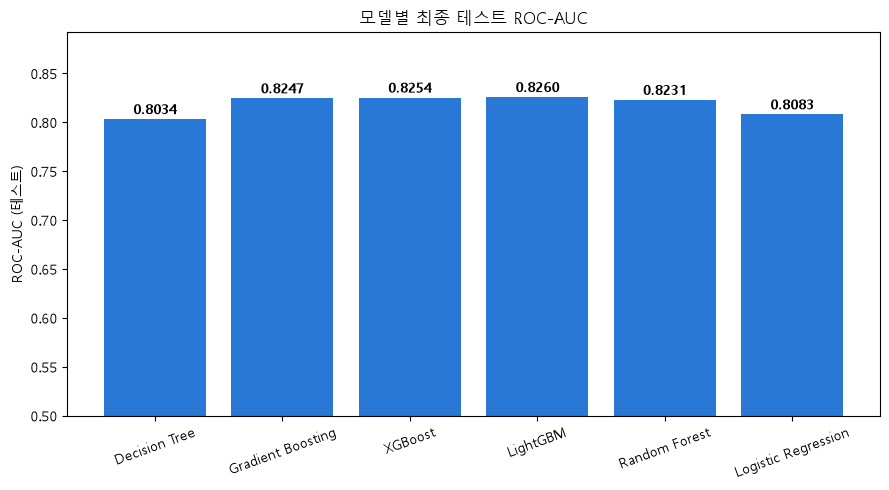

In [ ]:
final_results = {
    'Decision Tree': dt_test_auc_tuned,
    'Gradient Boosting': gb_test_auc_tuned,
    'XGBoost': xgb_test_auc_tuned,
    'LightGBM': lgbm_test_auc_ext,
    'Random Forest': rf_test_auc_tuned,
    'Logistic Regression': lr_test_auc_tuned,
}

summary = report_auc(final_results)
print(f"\n최고 성능 모델: {summary['best_model']} (ROC-AUC={summary['best_score']:.4f})")

plt.figure(figsize=(9, 5))
names = list(final_results.keys())
scores = list(final_results.values())
bars = plt.bar(names, scores, color='#2a78d6')
plt.ylim(0.5, max(scores) * 1.08)
plt.ylabel('ROC-AUC (테스트)')
plt.title('모델별 최종 테스트 ROC-AUC')
plt.xticks(rotation=20)
for b, s in zip(bars, scores):
    plt.text(b.get_x() + b.get_width() / 2, s + 0.005, f'{s:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
# 0.1s